# AERIS — Data Exploration
## OpenAQ DKI Jakarta Processed Dataset

Notebook ini adalah **Stage 1 — Dataset Understanding / EDA** untuk AERIS.

### Tujuan
- Memastikan seluruh CSV processed dapat dibaca.
- Memahami struktur dan kualitas data per sensor.
- Memeriksa coverage waktu, missing value, duplicate, frekuensi observasi, dan outlier sederhana.
- Memahami distribusi PM2.5 dan PM10.
- Menyiapkan keputusan yang diperlukan sebelum **Naive Baseline → Feature Engineering → XGBoost**.

> **Scope geografis:** DKI Jakarta (Jakarta Pusat, Selatan, Barat, Timur, Utara).
>
> **Source:** `data/processed/openaq_merged/` hasil merge + dedup + validasi geografis.
>
> Notebook ini **tidak melakukan imputasi** dan tidak mengubah dataset source.


## 1. Setup

Library utama:
- `pandas` — inspeksi dan analisis data.
- `numpy` — numerical operations.
- `matplotlib` — visualisasi.
- `pathlib` — path management.

Notebook dibuat relatif terhadap root repository agar dapat dipindahkan ke:
`ml/notebooks/01_data_exploration.ipynb`.


In [3]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Repository root: ml/notebooks -> ml -> repo
PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks" and PROJECT_ROOT.parent.name == "ml":
    PROJECT_ROOT = PROJECT_ROOT.parent.parent

DATA_DIR = PROJECT_ROOT / "data" / "processed" 

# Fallback untuk menjalankan notebook dari lokasi lain
if not DATA_DIR.exists():
    candidates = [
        Path("/mnt/data/aeris_eda_work"),
        Path("../data/processed"),
        Path("../../data/processed"),
        Path("../../../data/processed"),
    ]
    for candidate in candidates:
        if candidate.exists():
            DATA_DIR = candidate.resolve()
            break

print("Project root:", PROJECT_ROOT)
print("Data directory:", DATA_DIR)
print("Data directory exists:", DATA_DIR.exists())


Project root: /Users/geisarrampan/Project/AERIS-AI-Powered-Air-Intelligence-Platform
Data directory: /Users/geisarrampan/Project/AERIS-AI-Powered-Air-Intelligence-Platform/data/processed
Data directory exists: True


In [4]:
csv_files = sorted(DATA_DIR.glob("*.csv"))

if not csv_files:
    raise FileNotFoundError(f"No CSV files found in {DATA_DIR}")

print(f"CSV files found: {len(csv_files)}")
for path in csv_files:
    print("-", path.name)


CSV files found: 14
- BMKG_1__sensor17000275__pm25.csv
- East_Jakarta_Mayor_Office__sensor14313802__pm25.csv
- Jakarta_Central__sensor25072__pm25.csv
- Jakarta_South__sensor5077558__pm25.csv
- Jakarta__sensor7748546__pm10.csv
- Jakarta__sensor7748548__pm25.csv
- Jihan_Fauziah_Hamdi__sensor7325489__pm25.csv
- Jihan_Fauziah_Hamdi__sensor7971172__pm10.csv
- Jihan_Fauziah_Hamdi__sensor7978658__pm10.csv
- Krukut__sensor7666066__pm25.csv
- Krukut__sensor7970805__pm10.csv
- Krukut__sensor7978130__pm10.csv
- Rusunawa_Marunda__sensor14313805__pm25.csv
- West_Jakarta_Mayor_Office__sensor14313799__pm25.csv


## 2. Load seluruh sensor

Setiap CSV dipertahankan sebagai source per sensor terlebih dahulu. Setelah itu kita membuat dataframe gabungan untuk kebutuhan EDA.

**Catatan:** EDA ini hanya membaca data. Tidak ada nilai yang di-impute atau diubah pada file CSV.


In [5]:
EXPECTED_COLUMNS = [
    "datetime_utc",
    "value",
    "unit",
    "parameter",
    "sensor_id",
    "location_id",
    "location_name",
    "latitude",
    "longitude",
]

frames = []
load_errors = []

for path in csv_files:
    try:
        df = pd.read_csv(path)
        df["source_file"] = path.name
        frames.append(df)
    except Exception as exc:
        load_errors.append((path.name, str(exc)))

if load_errors:
    print("Load errors:")
    for item in load_errors:
        print(item)

data = pd.concat(frames, ignore_index=True)

print("Combined shape:", data.shape)
print("Columns:")
print(data.columns.tolist())


Combined shape: (117727, 10)
Columns:
['datetime_utc', 'value', 'unit', 'parameter', 'sensor_id', 'location_id', 'location_name', 'latitude', 'longitude', 'source_file']


In [6]:
missing_expected = [c for c in EXPECTED_COLUMNS if c not in data.columns]
unexpected = [c for c in data.columns if c not in EXPECTED_COLUMNS + ["source_file"]]

print("Missing expected columns:", missing_expected)
print("Additional columns:", unexpected)

display(data.head())


Missing expected columns: []
Additional columns: []


,datetime_utc,value,unit,parameter,sensor_id,location_id,location_name,latitude,longitude,source_file
0,2026-07-22 03:00:00+00:00,69.8,µg/m³,pm25,17000275,6455006,BMKG 1,-6.155769,106.842394,BMKG_1__sensor17000275__pm25.csv
1,2026-07-22 04:00:00+00:00,84.8,µg/m³,pm25,17000275,6455006,BMKG 1,-6.155769,106.842394,BMKG_1__sensor17000275__pm25.csv
2,2026-07-22 05:00:00+00:00,70.8,µg/m³,pm25,17000275,6455006,BMKG 1,-6.155769,106.842394,BMKG_1__sensor17000275__pm25.csv
3,2026-07-22 06:00:00+00:00,53.8,µg/m³,pm25,17000275,6455006,BMKG 1,-6.155769,106.842394,BMKG_1__sensor17000275__pm25.csv
4,2026-07-22 07:00:00+00:00,49.4,µg/m³,pm25,17000275,6455006,BMKG 1,-6.155769,106.842394,BMKG_1__sensor17000275__pm25.csv


## 3. Data types dan datetime validation

`datetime_utc` harus menjadi datetime sebelum membuat lag/rolling features pada tahap berikutnya.


In [7]:
data["datetime_utc"] = pd.to_datetime(data["datetime_utc"], errors="coerce", utc=True)

print(data.dtypes)
print("\nInvalid datetime:", data["datetime_utc"].isna().sum())


datetime_utc     datetime64[ns, UTC]
value                        float64
unit                          object
parameter                     object
sensor_id                      int64
location_id                    int64
location_name                 object
latitude                     float64
longitude                    float64
source_file                   object
dtype: object

Invalid datetime: 0


## 4. Dataset overview

Ringkasan global digunakan sebagai sanity check awal.


In [8]:
overview = pd.DataFrame({
    "metric": [
        "rows",
        "columns",
        "sensors",
        "locations",
        "parameters",
        "datetime_min",
        "datetime_max",
        "duplicate_rows",
        "missing_value_rows",
    ],
    "value": [
        len(data),
        data.shape[1],
        data["sensor_id"].nunique(),
        data["location_id"].nunique(),
        data["parameter"].nunique(),
        data["datetime_utc"].min(),
        data["datetime_utc"].max(),
        data.duplicated().sum(),
        data["value"].isna().sum(),
    ]
})

display(overview)
display(data["parameter"].value_counts().rename_axis("parameter").reset_index(name="rows"))


,metric,value
0,rows,117727
1,columns,10
2,sensors,14
3,locations,9
4,parameters,2
5,datetime_min,2019-12-31 17:00:00+00:00
6,datetime_max,2026-08-29 00:00:00+00:00
7,duplicate_rows,0
8,missing_value_rows,27406


,parameter,rows
0,pm25,110989
1,pm10,6738


## 5. Sensor inventory

Bagian ini adalah tabel utama untuk menentukan sensor mana yang layak masuk ke tahap modeling.

Kolom:
- `rows` — jumlah observasi.
- `start_utc`, `end_utc` — coverage.
- `span_days` — panjang span kalender.
- `missing_pct` — proporsi `value` yang missing.
- `duplicate_timestamp` — duplicate timestamp dalam sensor.
- `median_interval_hours` — median jarak antar-observasi.


In [9]:
def sensor_inventory(group):
    g = group.sort_values("datetime_utc")
    timestamps = g["datetime_utc"].dropna()
    intervals = timestamps.diff().dt.total_seconds().div(3600).dropna()

    return pd.Series({
        "rows": len(g),
        "parameter": ", ".join(sorted(g["parameter"].dropna().astype(str).unique())),
        "location_name": ", ".join(sorted(g["location_name"].dropna().astype(str).unique())),
        "start_utc": timestamps.min(),
        "end_utc": timestamps.max(),
        "span_days": (timestamps.max() - timestamps.min()).total_seconds() / 86400 if len(timestamps) else np.nan,
        "missing_pct": g["value"].isna().mean() * 100,
        "duplicate_timestamp": g["datetime_utc"].duplicated().sum(),
        "median_interval_hours": intervals.median() if len(intervals) else np.nan,
    })

inventory = (
    data.groupby("sensor_id", dropna=False)
    .apply(sensor_inventory, include_groups=False)
    .reset_index()
    .sort_values(["parameter", "missing_pct", "rows"])
)

display(inventory)


,sensor_id,rows,parameter,location_name,start_utc,end_utc,span_days,missing_pct,duplicate_timestamp,median_interval_hours
8,7978130,45,pm10,Krukut,2024-03-07 22:00:00+00:00,2024-03-09 18:00:00+00:00,1.833333,0.000000,0,1.0
9,7978658,45,pm10,Jihan Fauziah Hamdi,2024-03-07 22:00:00+00:00,2024-03-09 18:00:00+00:00,1.833333,0.000000,0,1.0
7,7971172,469,pm10,Jihan Fauziah Hamdi,2024-03-06 16:00:00+00:00,2024-05-25 23:00:00+00:00,80.291667,0.000000,0,1.0
4,7748546,2153,pm10,Jakarta,2024-01-25 08:00:00+00:00,2024-04-24 01:00:00+00:00,89.708333,0.000000,0,1.0
6,7970805,4026,pm10,Krukut,2024-03-06 16:00:00+00:00,2024-09-10 07:00:00+00:00,187.625000,0.000000,0,1.0
13,17000275,600,pm25,BMKG 1,2026-07-22 03:00:00+00:00,2026-08-26 05:00:00+00:00,35.083333,0.000000,0,1.0
2,7325489,1774,pm25,Jihan Fauziah Hamdi,2023-10-30 12:00:00+00:00,2024-05-25 23:00:00+00:00,208.458333,0.000000,0,1.0
3,7666066,4887,pm25,Krukut,2024-01-09 07:00:00+00:00,2024-09-10 07:00:00+00:00,245.000000,0.000000,0,1.0
5,7748548,8326,pm25,Jakarta,2024-01-25 08:00:00+00:00,2026-08-29 00:00:00+00:00,946.666667,0.000000,0,1.0
11,14313802,8494,pm25,East Jakarta Mayor Office,2023-09-30 16:00:00+00:00,2024-11-12 19:00:00+00:00,409.125000,0.000000,0,1.0


## 6. Missing values

Missing value tinggi tidak otomatis berarti sensor harus dibuang. Namun, missingness harus ditangani sebelum lag/rolling features dan forecasting.

Untuk Stage 1 kita **tidak melakukan imputasi**.


In [10]:
missing_by_sensor = (
    data.groupby(["sensor_id", "location_name", "parameter"], dropna=False)
    .agg(
        rows=("value", "size"),
        missing=("value", lambda s: s.isna().sum()),
        missing_pct=("value", lambda s: s.isna().mean() * 100),
    )
    .reset_index()
    .sort_values("missing_pct", ascending=False)
)

display(missing_by_sensor)


,sensor_id,location_name,parameter,rows,missing,missing_pct
0,25072,Jakarta Central,pm25,43070,18923,43.935454
1,5077558,Jakarta South,pm25,21192,8483,40.029256
2,7325489,Jihan Fauziah Hamdi,pm25,1774,0,0.000000
3,7666066,Krukut,pm25,4887,0,0.000000
4,7748546,Jakarta,pm10,2153,0,0.000000
5,7748548,Jakarta,pm25,8326,0,0.000000
6,7970805,Krukut,pm10,4026,0,0.000000
7,7971172,Jihan Fauziah Hamdi,pm10,469,0,0.000000
8,7978130,Krukut,pm10,45,0,0.000000
9,7978658,Jihan Fauziah Hamdi,pm10,45,0,0.000000


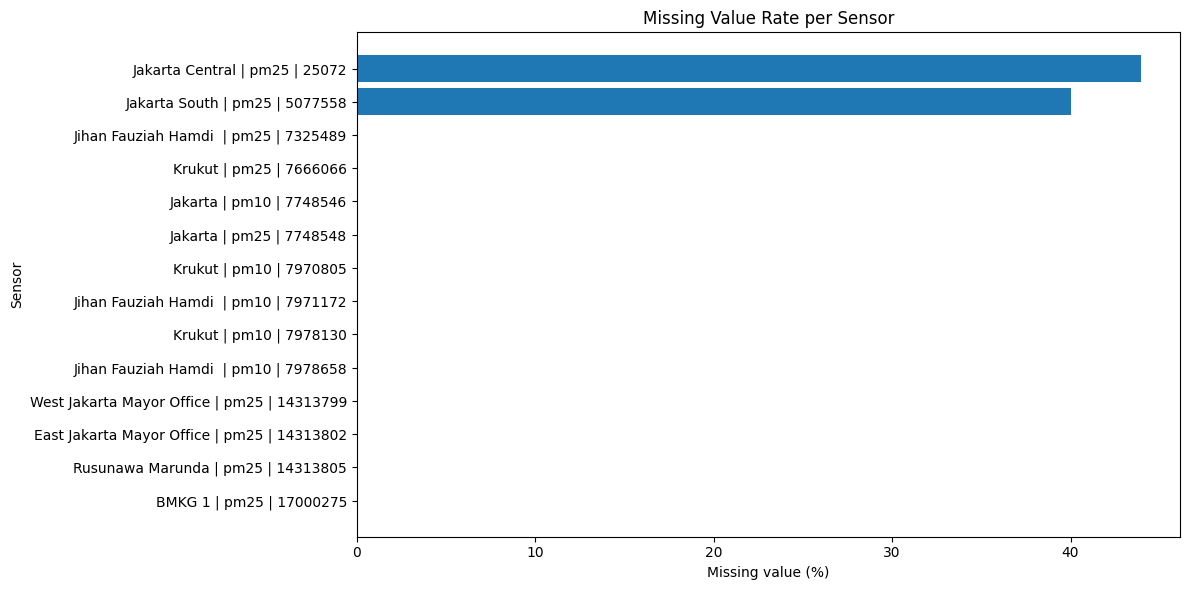

In [11]:
plt.figure(figsize=(12, 6))
plot_df = missing_by_sensor.copy()
plot_df["label"] = (
    plot_df["location_name"].astype(str)
    + " | "
    + plot_df["parameter"].astype(str)
    + " | "
    + plot_df["sensor_id"].astype(str)
)

plt.barh(plot_df["label"], plot_df["missing_pct"])
plt.xlabel("Missing value (%)")
plt.ylabel("Sensor")
plt.title("Missing Value Rate per Sensor")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


## 7. Coverage dan sampling interval

Forecasting membutuhkan pemahaman tentang apakah observasi benar-benar hourly atau memiliki gap besar.

Kita menghitung:
- median interval,
- mean interval,
- p95 interval,
- jumlah gap > 1 jam.


In [12]:
def interval_stats(group):
    ts = group.sort_values("datetime_utc")["datetime_utc"].dropna()
    diff_h = ts.diff().dt.total_seconds().div(3600).dropna()

    return pd.Series({
        "median_interval_h": diff_h.median() if len(diff_h) else np.nan,
        "mean_interval_h": diff_h.mean() if len(diff_h) else np.nan,
        "p95_interval_h": diff_h.quantile(0.95) if len(diff_h) else np.nan,
        "gaps_gt_1h": (diff_h > 1).sum(),
        "gaps_gt_6h": (diff_h > 6).sum(),
        "gaps_gt_24h": (diff_h > 24).sum(),
    })

interval_summary = (
    data.groupby("sensor_id", dropna=False)
    .apply(interval_stats, include_groups=False)
    .reset_index()
    .merge(
        data[["sensor_id", "location_name", "parameter"]].drop_duplicates("sensor_id"),
        on="sensor_id",
        how="left",
    )
)

display(interval_summary.sort_values("gaps_gt_24h", ascending=False))


,sensor_id,median_interval_h,mean_interval_h,p95_interval_h,gaps_gt_1h,gaps_gt_6h,gaps_gt_24h,location_name,parameter
5,7748548,1.0,2.729129,3.0,979.0,226.0,103.0,Jakarta,pm25
0,25072,1.0,1.073162,1.0,158.0,79.0,57.0,Jakarta Central,pm25
11,14313802,1.0,1.156129,1.0,55.0,16.0,13.0,East Jakarta Mayor Office,pm25
12,14313805,1.0,1.112288,1.0,53.0,13.0,13.0,Rusunawa Marunda,pm25
10,14313799,1.0,1.731203,1.0,34.0,13.0,10.0,West Jakarta Mayor Office,pm25
1,5077558,1.0,1.277571,1.0,57.0,15.0,7.0,Jakarta South,pm25
2,7325489,1.0,2.821771,2.0,234.0,15.0,7.0,Jihan Fauziah Hamdi,pm25
3,7666066,1.0,1.203438,2.0,274.0,26.0,3.0,Krukut,pm25
7,7971172,1.0,4.117521,3.0,37.0,9.0,3.0,Jihan Fauziah Hamdi,pm10
6,7970805,1.0,1.118758,1.0,107.0,26.0,3.0,Krukut,pm10


## 8. Duplicate check

Untuk time-series, duplicate timestamp perlu diketahui secara eksplisit.

Kita mengecek dua level:
1. duplicate seluruh baris;
2. duplicate timestamp dalam kombinasi sensor + parameter.


In [13]:
duplicate_timestamp = (
    data.groupby(["sensor_id", "parameter", "datetime_utc"], dropna=False)
    .size()
    .reset_index(name="count")
)

duplicate_timestamp = duplicate_timestamp[duplicate_timestamp["count"] > 1]

print("Duplicate sensor-parameter-timestamp groups:", len(duplicate_timestamp))
display(duplicate_timestamp.head(20))


Duplicate sensor-parameter-timestamp groups: 0


,sensor_id,parameter,datetime_utc,count


## 9. Value distribution

EDA distribusi membantu melihat range, skewness, dan nilai ekstrem.

**Penting:** outlier di tahap ini belum otomatis dihapus. Pada data polusi, lonjakan ekstrem bisa merupakan kejadian nyata dan relevan untuk anomaly detection.


In [14]:
distribution = (
    data.groupby(["parameter"], dropna=False)["value"]
    .agg(
        count="count",
        missing="size",
        mean="mean",
        median="median",
        std="std",
        min="min",
        p01=lambda s: s.quantile(0.01),
        p25=lambda s: s.quantile(0.25),
        p75=lambda s: s.quantile(0.75),
        p99=lambda s: s.quantile(0.99),
        max="max",
    )
    .reset_index()
)

display(distribution)


,parameter,count,missing,mean,median,std,min,p01,p25,p75,p99,max
0,pm10,6738,6738,57.388419,53.7,37.956297,0.543,8.65,36.6,68.2,195.0,754.0
1,pm25,83583,110989,39.413895,34.0,46.878011,0.000,4.00,20.0,50.0,116.0,985.0


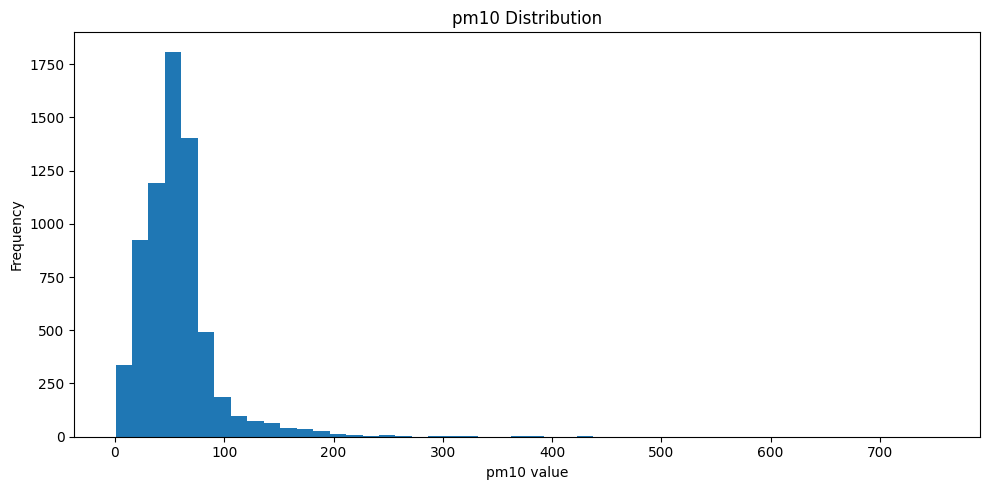

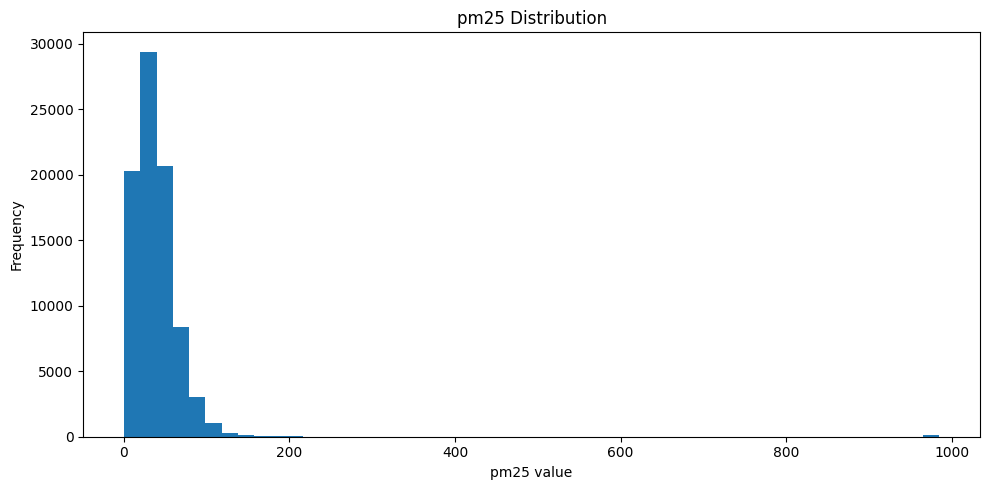

In [15]:
for parameter in sorted(data["parameter"].dropna().unique()):
    subset = data.loc[data["parameter"] == parameter, "value"].dropna()

    plt.figure(figsize=(10, 5))
    plt.hist(subset, bins=50)
    plt.xlabel(f"{parameter} value")
    plt.ylabel("Frequency")
    plt.title(f"{parameter} Distribution")
    plt.tight_layout()
    plt.show()


## 10. Time-series overview

Kita visualisasikan median harian per sensor agar sensor dengan jumlah data sangat besar tidak mendominasi plot.


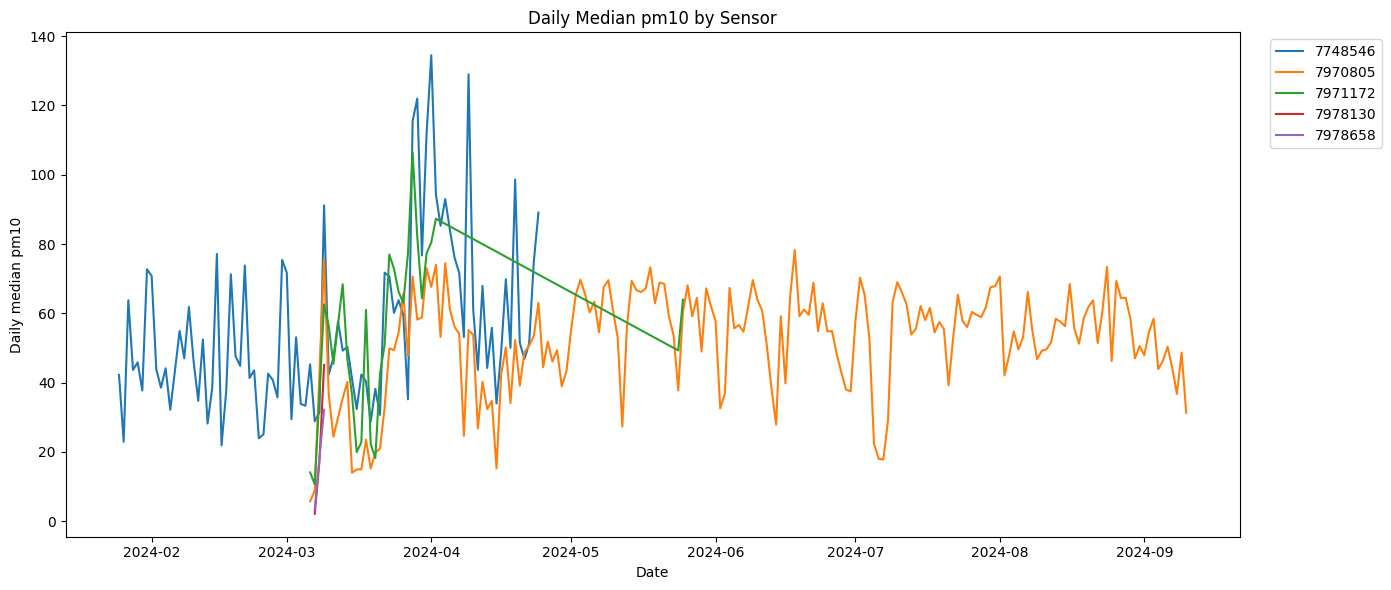

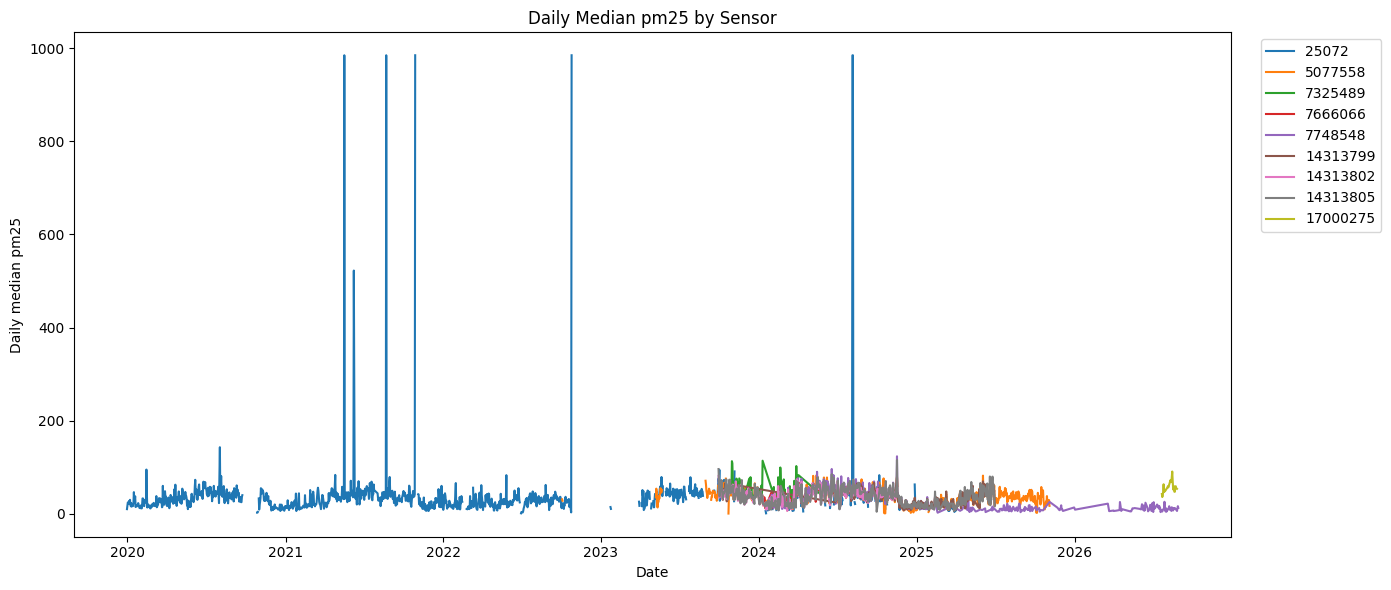

In [16]:
daily = (
    data.dropna(subset=["datetime_utc"])
    .assign(date=lambda d: d["datetime_utc"].dt.floor("D"))
    .groupby(["sensor_id", "location_name", "parameter", "date"], as_index=False)["value"]
    .median()
)

for parameter in sorted(daily["parameter"].dropna().unique()):
    subset = daily[daily["parameter"] == parameter]

    plt.figure(figsize=(14, 6))
    for sensor_id, sensor_df in subset.groupby("sensor_id"):
        plt.plot(sensor_df["date"], sensor_df["value"], label=str(sensor_id))

    plt.xlabel("Date")
    plt.ylabel(f"Daily median {parameter}")
    plt.title(f"Daily Median {parameter} by Sensor")
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()


## 11. Region / location inventory

Dataset processed sudah dibatasi pada scope DKI Jakarta. Notebook ini tetap menampilkan lokasi aktual agar kita dapat memastikan tidak ada sensor di luar scope yang masuk ke modeling dataset.


In [17]:
location_summary = (
    data.groupby(["location_name", "latitude", "longitude"], dropna=False)
    .agg(
        sensors=("sensor_id", "nunique"),
        parameters=("parameter", lambda s: ", ".join(sorted(s.dropna().unique()))),
        rows=("value", "size"),
    )
    .reset_index()
    .sort_values("rows", ascending=False)
)

display(location_summary)


,location_name,latitude,longitude,sensors,parameters,rows
3,Jakarta Central,-6.182536,106.834235,1,pm25,43070
4,Jakarta South,-6.236704,106.793244,1,pm25,21192
7,Rusunawa Marunda,-6.096695,106.960983,1,pm25,13787
2,Jakarta,-6.096570,106.961350,2,"pm10, pm25",10479
6,Krukut,-6.159382,106.818018,3,"pm10, pm25",8958
8,West Jakarta Mayor Office,-6.185880,106.737892,1,pm25,8859
1,East Jakarta Mayor Office,-6.214719,106.944138,1,pm25,8494
5,Jihan Fauziah Hamdi,-6.221069,106.825500,3,"pm10, pm25",2288
0,BMKG 1,-6.155769,106.842394,1,pm25,600


## 12. Sensor dengan coverage pendek

Sensor dengan jumlah observasi sangat sedikit tidak ideal untuk lag/rolling time-series features.

Kita tidak menghapusnya dari processed dataset di notebook ini. Kita hanya memberi flag untuk keputusan modeling.


In [18]:
modeling_flags = inventory.copy()

modeling_flags["short_coverage_flag"] = (
    (modeling_flags["rows"] < 100) |
    (modeling_flags["span_days"] < 30)
)

modeling_flags["high_missing_flag"] = modeling_flags["missing_pct"] >= 40

modeling_flags["usable_for_baseline_candidate"] = (
    (~modeling_flags["short_coverage_flag"]) &
    (~modeling_flags["high_missing_flag"]) &
    (modeling_flags["duplicate_timestamp"] == 0)
)

display(
    modeling_flags[
        [
            "sensor_id", "location_name", "parameter", "rows",
            "span_days", "missing_pct", "duplicate_timestamp",
            "short_coverage_flag", "high_missing_flag",
            "usable_for_baseline_candidate"
        ]
    ].sort_values(["parameter", "usable_for_baseline_candidate", "missing_pct"])
)


,sensor_id,location_name,parameter,rows,span_days,missing_pct,duplicate_timestamp,short_coverage_flag,high_missing_flag,usable_for_baseline_candidate
8,7978130,Krukut,pm10,45,1.833333,0.000000,0,True,False,False
9,7978658,Jihan Fauziah Hamdi,pm10,45,1.833333,0.000000,0,True,False,False
7,7971172,Jihan Fauziah Hamdi,pm10,469,80.291667,0.000000,0,False,False,True
4,7748546,Jakarta,pm10,2153,89.708333,0.000000,0,False,False,True
6,7970805,Krukut,pm10,4026,187.625000,0.000000,0,False,False,True
1,5077558,Jakarta South,pm25,21192,1128.041667,40.029256,0,False,True,False
0,25072,Jakarta Central,pm25,43070,1925.833333,43.935454,0,False,True,False
13,17000275,BMKG 1,pm25,600,35.083333,0.000000,0,False,False,True
2,7325489,Jihan Fauziah Hamdi,pm25,1774,208.458333,0.000000,0,False,False,True
3,7666066,Krukut,pm25,4887,245.000000,0.000000,0,False,False,True


## 13. EDA conclusions / handoff

Notebook ini berfungsi sebagai tahap eksplorasi dan validasi dataset sebelum masuk ke pembangunan model prediksi.

Source utama yang dipakai saat ini adalah file CSV di processed, bukan folder openaq_merged. Data raw tetap tersimpan di raw, sedangkan file di processed merupakan dataset yang sudah dipilih untuk analisis lanjutan.

Dari hasil EDA, dataset sudah menunjukkan struktur yang konsisten secara umum: kolom utama seperti datetime_utc, value, parameter, sensor_id, location_id, location_name, latitude, dan longitude tersedia pada hampir seluruh file. Proses parsing datetime_utc ke format datetime UTC sudah sesuai, dan dataset bisa dipilah berdasarkan sensor dan parameter.

Namun, kualitas tiap sensor tidak seragam. Ada perbedaan signifikan dalam:

coverage waktu,
missing value,
jumlah observasi,
interval sampling,
kemungkinan duplicate timestamp.
Ini artinya, tidak semua sensor layak langsung dipakai untuk baseline model. Beberapa sensor bisa dipakai sebagai kandidat baseline, sementara sensor dengan coverage pendek atau missing value tinggi perlu dipertimbangkan ulang sebelum masuk ke phase modeling.

Untuk tahap berikutnya, kita tidak perlu melakukan random split. Karena data ini berbasis time series, split harus dilakukan secara kronologis agar evaluasi mencerminkan kondisi dunia nyata. Baseline naive persistence atau model sederhana akan digunakan sebagai benchmark sebelum menerapkan feature engineering dan model yang lebih kompleks.

Langkah berikutnya yang paling masuk akal adalah:

menggabungkan semua CSV dari processed,
menyortir berdasarkan datetime_utc,
memilih parameter target seperti PM2.5 atau PM10,
membangun feature temporal (hour, day, month, weekday, lag, rolling window),
membuat train/test split berdasarkan waktu,
membangun baseline model,
mengevaluasi dengan MAE, RMSE, dan R2,
baru lanjut ke model seperti XGBoost atau model tree-based.
Dengan kata lain, notebook ini sudah berhasil melakukan audit dataset dan memberikan handoff yang valid ke tahap modeling. Data siap untuk diproses lebih lanjut, tetapi belum cukup untuk langsung dikatakan “siap train” tanpa pemilihan sensor dan feature yang tepat.



In [19]:
# Compact machine-readable EDA summary for downstream work
eda_summary = {
    "total_rows": int(len(data)),
    "total_csv": int(len(csv_files)),
    "unique_sensors": int(data["sensor_id"].nunique()),
    "unique_locations": int(data["location_id"].nunique()),
    "parameters": sorted(data["parameter"].dropna().astype(str).unique().tolist()),
    "datetime_min": str(data["datetime_utc"].min()),
    "datetime_max": str(data["datetime_utc"].max()),
    "missing_value_pct": float(data["value"].isna().mean() * 100),
    "duplicate_full_rows": int(data.duplicated().sum()),
    "duplicate_sensor_timestamp_groups": int(len(duplicate_timestamp)),
}

eda_summary


{'total_rows': 117727,
 'total_csv': 14,
 'unique_sensors': 14,
 'unique_locations': 9,
 'parameters': ['pm10', 'pm25'],
 'datetime_min': '2019-12-31 17:00:00+00:00',
 'datetime_max': '2026-08-29 00:00:00+00:00',
 'missing_value_pct': 23.27928172806578,
 'duplicate_full_rows': 0,
 'duplicate_sensor_timestamp_groups': 0}